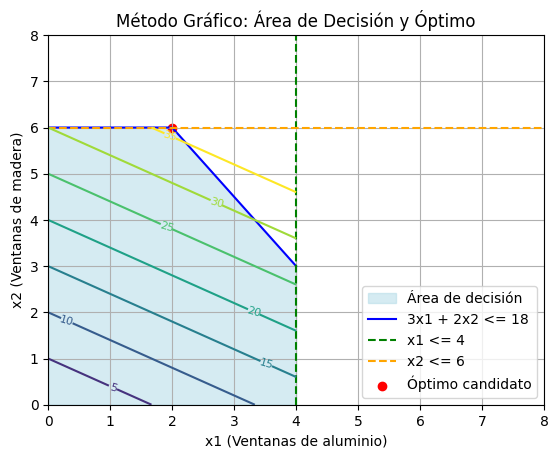

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 4, 200)  #restrc x1 <= 4
x2 = np.linspace(0, 6, 200)  # restric x2 <= 6
x2_ensamblaje = (18 - 3 * x1) / 2 #restricción 3x1 + 2x2 <= 18

plt.fill_between(x1, 0, np.minimum(6, x2_ensamblaje), color='lightblue', alpha=0.5, label="Área de decisión")
plt.plot(x1, np.minimum(6, x2_ensamblaje), label="3x1 + 2x2 <= 18", color="blue")
plt.axvline(x=4, label="x1 <= 4", color="green", linestyle="--")
plt.axhline(y=6, label="x2 <= 6", color="orange", linestyle="--")

X1, X2 = np.meshgrid(x1, x2)
Z = 3 * X1 + 5 * X2
contour = plt.contour(X1, X2, Z, levels=np.arange(0, 40, 5), cmap="viridis")
plt.clabel(contour, inline=True, fontsize=8)

#Óptimo que es candidatos
optimal_x1 = 2 
optimal_x2 = 6  
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.scatter(optimal_x1, optimal_x2, color='red', label="Óptimo candidato")
plt.title("Método Gráfico: Área de Decisión y Óptimo")
plt.xlabel("x1 (Ventanas de aluminio)")
plt.ylabel("x2 (Ventanas de madera)")
plt.legend()
plt.grid()
plt.show()

In [2]:
from gurobipy import Model, GRB

model = Model("Ventanas_Optimizacion")

xa = model.addVar(name="xa", vtype=GRB.CONTINUOUS, lb=0)  #ventanas de aluminio
xm = model.addVar(name="xm", vtype=GRB.CONTINUOUS, lb=0)  #venntanas de madera

model.setObjective(3 * xa + 5 * xm, GRB.MAXIMIZE)

model.addConstr(xa <= 4, name = "Capacidad_Punto_1")  #restricción p1
model.addConstr(xm <= 6, name= "Capacidad_Punto_2")  # restr p2
model.addConstr(3 * xa + 2 * xm <= 18, name="Capacidad_Punto_3") #restricción en p3

model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Estado del modelo: Óptimo")
    print(f"Ventanas de aluminio (x1): {xa.x}")
    print(f"Ventanas de madera (x2): {xm.x}")
    print(f"Ganancia total: {model.objVal}")
else:
    print(f"Estado del modelo: {model.status}")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-06-16
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3 rows, 2 columns and 4 nonzeros
Model fingerprint: 0xa8ab4c1c
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [3e+00, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 2e+01]
Presolve removed 2 rows and 0 columns
Presolve time: 0.01s
Presolved: 1 rows, 2 columns, 2 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.5000000e+01   1.500000e+00   0.000000e+00      0s
       1    3.6000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.600000000e+01
Estado del modelo